<a href="https://colab.research.google.com/github/Julian27R/Aprendizaje_Maquina/blob/main/PARCIAL2_TAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **PUNTO A:  Modelos y Problemas de optimización**

#================== Modelos de Aprendizaje de Máquina ===================

## **1. PCA — Principal Component Analysis**

* ### Descripción
Técnica de reducción de dimensionalidad que proyecta datos de alta dimensión a un espacio de menor dimensión **preservando la mayor cantidad de varianza posible**.  

* ### Perspectiva generativa  
Sea la matriz de datos $X \in \mathbb{R}^{N\times P}$, con  
$N=$ número de muestras, $P=$ número de características.

  Se asume un espacio latente de dimensión $M<P$ con  
$Z \in \mathbb{R}^{N\times M}$ y $W \in \mathbb{R}^{P\times M}$.

$$
\begin{aligned}
X &= ZW^{\top}\\
Z &= XW
\end{aligned}
$$

* ### Problema de optimización  
$$
\begin{aligned}
\\ W^* = \min_{W}\;&\lVert X - XWW^{\top}\rVert_F^{2}\\[4pt]
\text{s.t. }& WW^{\top}=I
\end{aligned}
$$

* ### Perspectiva de varianza (geométrica)  
Matriz de covarianza con datos centrados:  
$\Sigma = \tfrac{1}{N}X^{\top}X$.
$$
\begin{aligned}
\\\ W^* = \max_{W}\;&\operatorname{tr}\!\bigl(W^{\top}\Sigma W\bigr)\\[4pt]
\text{s.t. }& WW^{\top}=I
\end{aligned}
$$
Los vectores propios asociados a los $M$ mayores autovalores de $\Sigma$ forman $W^*$.



## **2. UMAP — Uniform Manifold Approximation and Projection**

* ### Probabilidad de conectividad en el espacio original  
$$
p_{nm} = \exp\!\Bigl(-\tfrac{\lVert x_n - x_m\rVert - \rho_n}{\sigma_n}\Bigr)
$$
donde $\rho_n$ es la distancia al vecino más cercano de $x_n$ y  
$\sigma_n$ la escala adaptativa.


* ### Simetrización del grafo  
$$
p'_{nm} \;=\; p_{nm} + p_{mn} - p_{nm}p_{mn}
$$

* ### Probabilidad en el espacio de baja dimensión  
$$
q_{nm} = \bigl(1 + a\,\lVert z_n - z_m\rVert^{2b}\bigr)^{-1}
$$
con parámetros $a,b$ que controlan la forma de la distribución.

* ### Función objetivo (entropía cruzada)  
$$
C(P,Q) \;=\;
\sum_{n,m}
\Bigl[
 -\,p'_{nm}\,\log q_{nm}
 -(1-p'_{nm})\log\bigl(1-q_{nm}\bigr)
\Bigr]
$$



## **3. K Neighbors Classifier (KNN)**

* Predicción para un punto $x$:

$$
\hat{y}(x)=\operatorname{mode}\bigl\{\,y_i : x_i \in N_K(x)\bigr\}
$$

* Interpretación como votación mayoritaria:

$$
\hat{y}(x) \;=\;
\operatorname*{arg\,max}_{c}
\sum_{x_i\in N_K(x)} \mathbf{1}\!\bigl(y_i = c\bigr)
$$



## **4. SVC — *Support Vector Classifier* (SVM lineal)**
* ### Modelo y predicción  
$$
f(x) = W^{\top}x + b,
\qquad
\hat{y} = \operatorname{sign}\bigl(W^{\top}x + b\bigr)
$$

* ### Problema de optimización (datos separables)  
$$
\begin{aligned}
\min_{W,b}\;&\tfrac12\lVert W\rVert^{2}\\[4pt]
\text{s.\,t. }& y_i\bigl(W^{\top}x_i + b\bigr) \ge 1,\;\forall i
\end{aligned}
$$

* ### Problema de optimización (margen suave)  
$$
\begin{aligned}
\min_{W,b,\{\xi_i\}}\;& \tfrac12\lVert W\rVert^{2} + C\sum_i \xi_i \\[4pt]
\text{s.\,t. }& y_i\bigl(W^{\top}x_i + b\bigr) \ge 1 - \xi_i,\\
& \xi_i \ge 0,\;\forall i
\end{aligned}
$$
Donde $\xi_i$ mide la violación del margen y $C$ controla el balance entre margen ancho y errores.


## **5. CNN (Convolutional Neural Network)**
El objetivo es aprender una función de clasificación

$$
f_{\theta}\;:\;\mathbb{R}^{1\times16\times16}\;\longrightarrow\;\{0,1,\dots,9\}
$$
donde
* $x_i \in \mathbb{R}^{1\times16\times16}$ — imagen en escala de grises de $16\times16$ píxeles  
* $y_i \in \{0,1,\dots,9\}$ — etiqueta de clase  
* $f_{\theta}(\cdot)$ — red convolucional parametrizada por $\theta$ que produce **logits** (puntajes sin normalizar)

La salida se transforma en probabilidades mediante *soft-max*
$$
\hat y_i \;=\; \operatorname{softmax}\!\bigl(f_{\theta}(x_i)\bigr)\;\in\;[0,1]^{10}.
$$

* ## Arquitectura del modelo (CNN)
    El modelo **BetterCNN** contiene
    1. **Tres bloques convolucionales**  
      * Convolución 2-D — extrae patrones locales  
      * Batch Normalization — estabiliza la distribución de activaciones  
      * ReLU — introduce no linealidad  
      * MaxPooling — reduce la resolución espacial  
    2. **Capa *fully connected***  
      * Aplanamiento del tensor  
      * Capa densa intermedia + ReLU  
      * Dropout (regularización)  
      * Capa de salida con 10 unidades (una por clase)


* ## Problema de optimización
El entrenamiento minimiza la *entropía cruzada* en el conjunto de entrenamiento
$$
\theta^* \;=\;
\operatorname*{arg\,min}_{\theta}
\Bigl[
-\sum_{i=1}^{N} \log \hat y_{i,y_i}
\Bigr]
=
\operatorname*{arg\,min}_{\theta}
\Bigl[
-\sum_{i=1}^{N}
\log\!\Bigl(
\tfrac{e^{z_{i,y_i}}}{\sum_{c=1}^{10} e^{z_{i,c}}}
\Bigr)
\Bigr],
$$
  donde
  * $\hat y_{i,y_i}$ — probabilidad predicha para la clase correcta $y_i$  
  * $z_{i,c}$ — logit para la clase $c$  
  * $\theta$ — todos los parámetros de la red  
  * $N$ — número de ejemplos de entrenamiento  
  **Optimizador** AdamW (gradiente adaptativo + $L_2$) con *scheduler* ReduceLROnPlateau.

* ## Evaluación del clasificador
  * **Exactitud (Accuracy)**  
    $\mathrm{Acc} = \dfrac{\text{aciertos}}{N_{\text{test}}}$  
  * **F1-score macro** — promedio del F1 por clase  
  * **Matriz de confusión** — patrón de errores por clase  
  * **Curva ROC** macro-promediada (OvR) — relación sensibilidad / especificidad multiclase  

---




# **PUNTO B: Proyección y Análisis del Espacio Latente de USPS con PCA y UMAP.**

##**1. Descargar y Cargar el Dataseet USPS.h5 desde el Google Drive**

In [1]:
!pip install gdown --upgrade --quiet

In [2]:
# -------------------------------
# 1. IMPORTAR LIBRERÍAS
# -------------------------------
import gdown                  # Descarga directa desde Google Drive
import pandas as pd           # Manejo de datos (por si lo necesitas después)
from IPython.display import display, HTML  # Visualización mejorada
from pathlib import Path
import h5py

# -------------------------------
# 2. CONFIGURACIÓN INICIAL
# -------------------------------
FILE_ID = "1dFMFLDBRxkbtHlZoShyfiSBBt5uiwJHy"   # ID del archivo en Drive
NOMBRE_ARCHIVO = "usps.h5"                      # Nombre local

# -------------------------------
# 3. DESCARGA DEL ARCHIVO
# -------------------------------
url = f"https://drive.google.com/uc?id={FILE_ID}"
gdown.download(url, NOMBRE_ARCHIVO, quiet=False)

# -------------------------------
# 4. CARGA DEL ARCHIVO HDF5
# -------------------------------
path = Path(NOMBRE_ARCHIVO)  # Ruta al archivo recién descargado

with h5py.File(path, 'r') as hf:
    # Conjuntos de entrenamiento
    train_grp = hf['train']
    X_tr = train_grp['data'][:]
    y_tr = train_grp['target'][:]

    # Conjuntos de prueba
    test_grp = hf['test']
    X_te = test_grp['data'][:]
    y_te = test_grp['target'][:]


# -------------------------------
# 5. VERIFICACIÓN DE DIMENSIONES
# -------------------------------
print("Dimensiones:")
print("X_tr:", X_tr.shape)
print("y_tr:", y_tr.shape)
print("X_te:", X_te.shape)
print("y_te:", y_te.shape)


Downloading...
From: https://drive.google.com/uc?id=1dFMFLDBRxkbtHlZoShyfiSBBt5uiwJHy
To: /content/usps.h5
100%|██████████| 2.91M/2.91M [00:00<00:00, 44.3MB/s]


Dimensiones:
X_tr: (7291, 256)
y_tr: (7291,)
X_te: (2007, 256)
y_te: (2007,)


In [3]:
!pip install --quiet scikit-learn umap-learn matplotlib

##**1. Preprocesamiento de datos:**
Aplanar las imágenes 16 × 16 → vectores de 256 px y estandarizar cada característica (media 0, varianza 1). PCA es sensible a la escala y UMAP usa distancias Euclídeas; ambas se benefician del escalado.

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# ----- 1) Aplana solo si es necesario -----
if X_tr.ndim == 3:                       # (N, 16, 16)
    X_train = X_tr.reshape(len(X_tr), -1).astype(np.float32)
    X_test  = X_te.reshape(len(X_te), -1).astype(np.float32)
else:                                    # (N, 256)  ya aplanado
    X_train = X_tr.astype(np.float32)
    X_test  = X_te.astype(np.float32)

# ----- 2) Estandariza -----
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

# ----- 3) Etiquetas (garantizamos int) -----
y_train = y_tr.astype(int)
y_test  = y_te.astype(int)

# Se define un conjunto de submuestras para facilidad de calculos
X_train_std = X_train_std[:3000]
y_train = y_train[:3000]

print("Shapes después del preprocesamiento:")
print("X_train_std:", X_train_std.shape)
print("X_test_std :", X_test_std.shape)
print("y_train    :", y_train.shape)
print("y_test     :", y_test.shape)

Shapes después del preprocesamiento:
X_train_std: (3000, 256)
X_test_std : (2007, 256)
y_train    : (3000,)
y_test     : (2007,)


##**2. Reducir dimensión:**
###2.1. PCA a 2 dimensiones

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_train_std)     # shape → (N, 2)

###2.2. UMAP a 2 dimensiones
Se probara distintos valores de n_neighbors.
min_dist controla cuán compactos son los grupos; lo fijamos a 0.1 para que la comparación dependa solo de n_neighbors.

In [6]:
import umap

emb_umap = {}
for k in (5, 15, 50):                 # pequeño, medio y grande
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=k,
        min_dist=0.1,
        metric="euclidean",
        random_state=0,
    )
    emb_umap[k] = reducer.fit_transform(X_train_std)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


##**3. Visualizar con colores + miniaturas**
Se usara un scatter con mapa de color tab10 (10 dígitos) y sobrepondremos una imagen representativa por clase. Esto facilita identificar cómo se distribuyen los dígitos en el espacio latente.

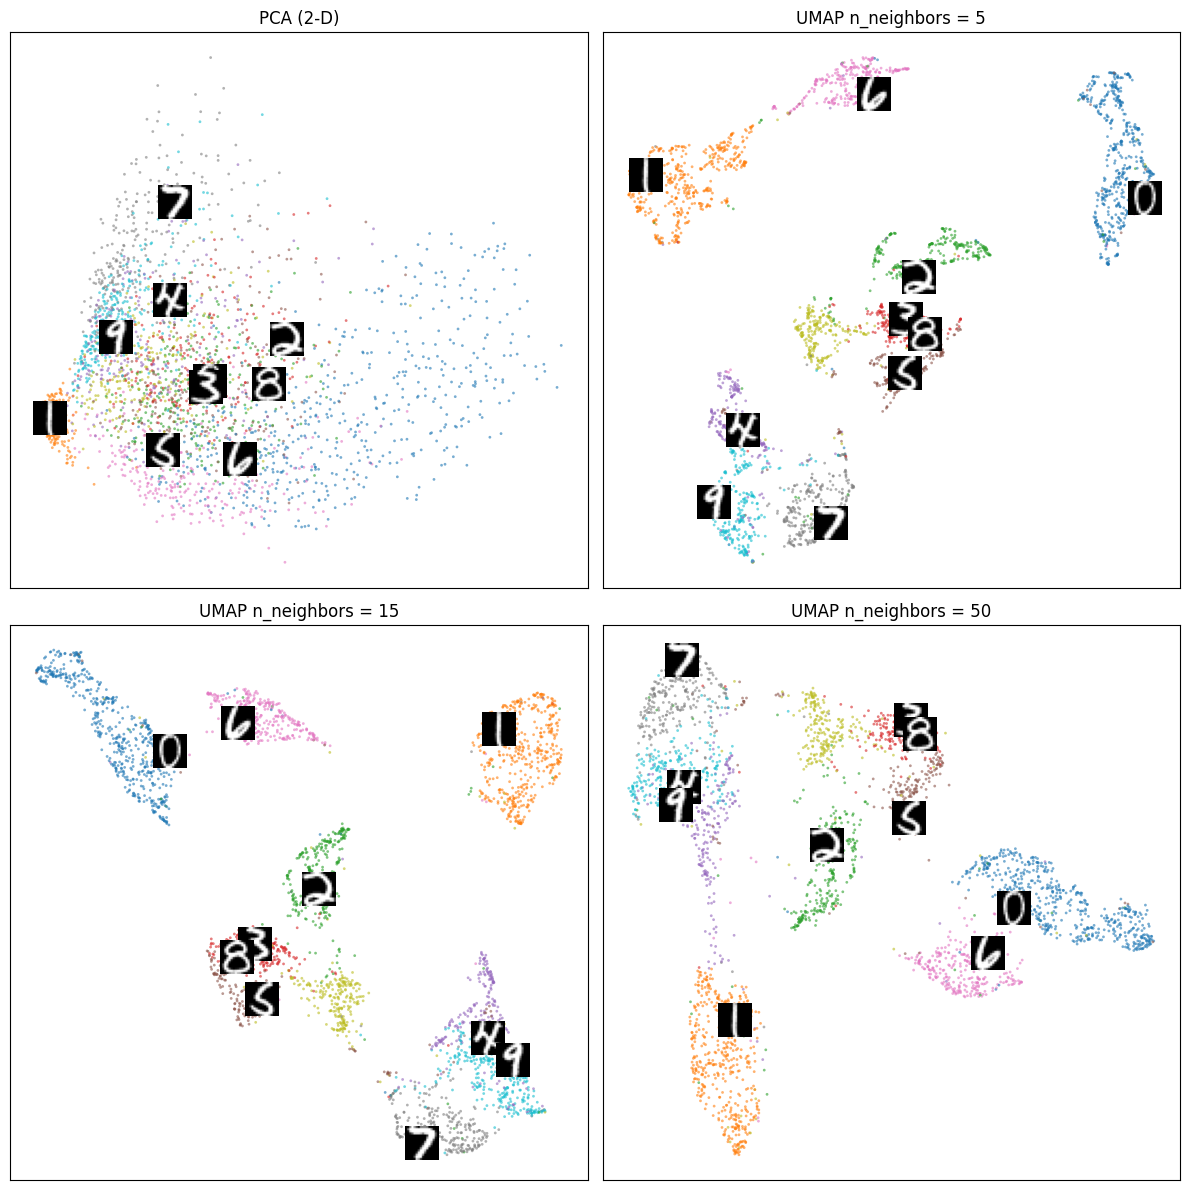

In [12]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def plot_embedding(ax, emb, title):
    sc = ax.scatter(
        emb[:, 0], emb[:, 1],
        c=y_train, cmap="tab10", s=4, alpha=0.6, linewidths=0
    )
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    # Añadimos una miniatura por dígito
    for digit in range(10):
        idx = np.where(y_train == digit)[0]
        if idx.size == 0: continue
        med = idx[len(idx)//2]            # muestra “mediana” de la clase
        xy  = emb[med]
        thumb = OffsetImage(X_train[med].reshape(16,16), cmap="gray", zoom=1.5)
        ax.add_artist(AnnotationBbox(thumb, xy, frameon=False))

# Dibujamos las cuatro proyecciones
fig, axs = plt.subplots(2, 2, figsize=(12,12))
plot_embedding(axs[0,0], X_pca,            "PCA (2-D)")
plot_embedding(axs[0,1], emb_umap[5],      "UMAP n_neighbors = 5")
plot_embedding(axs[1,0], emb_umap[15],     "UMAP n_neighbors = 15")
plot_embedding(axs[1,1], emb_umap[50],     "UMAP n_neighbors = 50")
plt.tight_layout(); plt.show()

---

# **PUNTO C: Modelado y Evaluación de Clasificadores para la Base de Datos USPS**

In [13]:
# CELDA H2 ─ Helper único: Confusion + ROC en un subplot 1×2
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

def plot_confusion_roc(model_name, y_true, y_pred, y_score, classes=np.arange(10)):
    """
    Dibuja (izq) matriz de confusión normalizada y (der) curva ROC macro-average.
    Los textos de la matriz se reducen para evitar solaparse.
    """
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # ── Matriz de confusión ────────────────────────────────────────
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize='true',
        values_format='.2f',          # solo dos decimales
        cmap='Blues',
        ax=axs[0],
        colorbar=False
    )
    axs[0].set_title(f"{model_name} – Confusion Matrix")
    # Reducimos el tamaño de letra de los textos dentro de las celdas
    for text in disp.text_.ravel():
        text.set_fontsize(7)

    # ── Curva ROC macro-average ───────────────────────────────────
    y_bin = label_binarize(y_true, classes=classes)
    auc   = roc_auc_score(y_bin, y_score, average='macro')
    RocCurveDisplay.from_predictions(
        y_bin.ravel(), y_score.ravel(),
        ax=axs[1],
        name=f"{model_name} (AUC {auc:.3f})",
        linewidth=1.5,
    )
    axs[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axs[1].set_title(f"{model_name} – ROC macro (OvR)")

    plt.tight_layout()
    plt.show()


## **1. K-Nearest Neighbors (KNN)**

─ KNN ─
Accuracy : 0.9142999501743896
F1_macro : 0.9068507125210254
              precision    recall  f1-score   support

           0     0.9169    0.9833    0.9489       359
           1     0.9700    0.9811    0.9755       264
           2     0.9005    0.8687    0.8843       198
           3     0.9012    0.8795    0.8902       166
           4     0.9227    0.8350    0.8766       200
           5     0.9167    0.8250    0.8684       160
           6     0.9455    0.9176    0.9313       170
           7     0.8364    0.9388    0.8846       147
           8     0.9412    0.8675    0.9028       166
           9     0.8660    0.9492    0.9057       177

    accuracy                         0.9143      2007
   macro avg     0.9117    0.9046    0.9069      2007
weighted avg     0.9156    0.9143    0.9137      2007



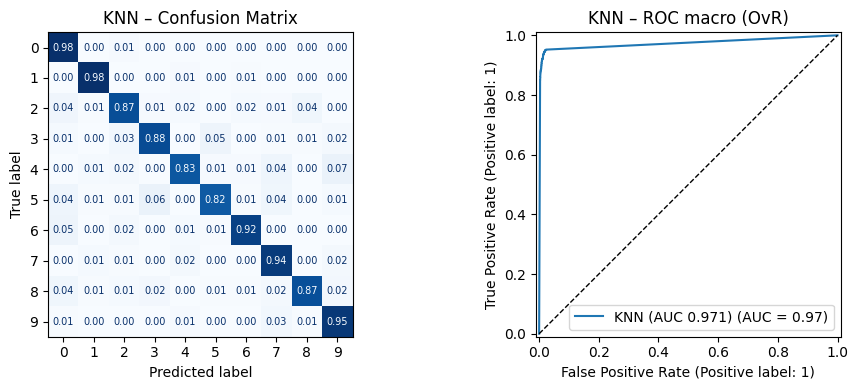

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

knn = KNeighborsClassifier(n_neighbors=3, weights='distance', n_jobs=-1)
knn.fit(X_train_std, y_train)

y_pred_knn = knn.predict(X_test_std)
print("─ KNN ─")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("F1_macro :", f1_score(y_test, y_pred_knn, average='macro'))
print(classification_report(y_test, y_pred_knn, digits=4))

plot_confusion_roc("KNN", y_test, y_pred_knn, knn.predict_proba(X_test_std))

## **2. SVC con kernel RBF**

Mejores hiperparámetros SVC: {'C': 100, 'gamma': 0.001}

─ SVC RBF ─
Accuracy : 0.9332336821126059
F1_macro : 0.9274844302681691
              precision    recall  f1-score   support

           0     0.9413    0.9833    0.9619       359
           1     0.9961    0.9659    0.9808       264
           2     0.9179    0.9040    0.9109       198
           3     0.8848    0.8795    0.8822       166
           4     0.9000    0.9450    0.9220       200
           5     0.8589    0.8750    0.8669       160
           6     0.9691    0.9235    0.9458       170
           7     0.9645    0.9252    0.9444       147
           8     0.9304    0.8855    0.9074       166
           9     0.9396    0.9661    0.9526       177

    accuracy                         0.9332      2007
   macro avg     0.9303    0.9253    0.9275      2007
weighted avg     0.9339    0.9332    0.9332      2007



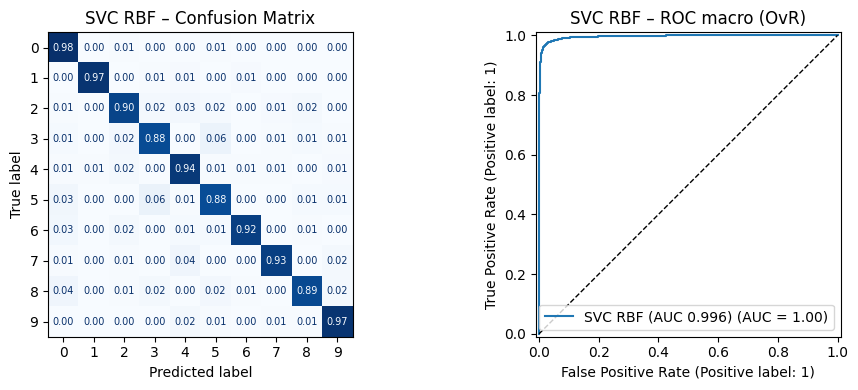

In [15]:
# CELDA 2
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Usamos un subset de 3 000 muestras para acelerar la búsqueda
subset = 3000
svc_base = SVC(kernel='rbf', probability=True)

param_grid = {'C':[1,10,100], 'gamma':[1e-3,1e-2,1e-1]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

grid = GridSearchCV(svc_base, param_grid, cv=cv, n_jobs=-1, verbose=0)
grid.fit(X_train_std[:subset], y_train[:subset])

print("Mejores hiperparámetros SVC:", grid.best_params_)

# Reentrenamos con TODO el training set y los mejores hiperparámetros
svc = grid.best_estimator_
svc.fit(X_train_std, y_train)

y_pred_svc = svc.predict(X_test_std)
print("\n─ SVC RBF ─")
print("Accuracy :", accuracy_score(y_test, y_pred_svc))
print("F1_macro :", f1_score(y_test, y_pred_svc, average='macro'))
print(classification_report(y_test, y_pred_svc, digits=4))

plot_confusion_roc("SVC RBF", y_test, y_pred_svc, svc.predict_proba(X_test_std))

## **3. CNN(Deep Learning)**

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01/30 | loss 2.2035 | val_acc 0.1315
Epoch 02/30 | loss 0.9152 | val_acc 0.7578
Epoch 03/30 | loss 0.4175 | val_acc 0.7932
Epoch 04/30 | loss 0.2907 | val_acc 0.9382
Epoch 05/30 | loss 0.2251 | val_acc 0.8884
Epoch 06/30 | loss 0.1952 | val_acc 0.9302
Epoch 07/30 | loss 0.1705 | val_acc 0.9606
Epoch 08/30 | loss 0.1480 | val_acc 0.9312
Epoch 09/30 | loss 0.1359 | val_acc 0.9502
Epoch 10/30 | loss 0.1205 | val_acc 0.9701
Epoch 11/30 | loss 0.1162 | val_acc 0.4494
Epoch 12/30 | loss 0.1226 | val_acc 0.9073
Epoch 13/30 | loss 0.1078 | val_acc 0.6976
Epoch 14/30 | loss 0.1024 | val_acc 0.4345
Epoch 15/30 | loss 0.0913 | val_acc 0.9601
Epoch 16/30 | loss 0.0807 | val_acc 0.9601
Epoch 17/30 | loss 0.0769 | val_acc 0.9427
Epoch 18/30 | loss 0.0792 | val_acc 0.7653
Epoch 19/30 | loss 0.0758 | val_acc 0.9711
Epoch 20/30 | loss 0.0649 | val_acc 0.9666
Epoch 21/30 | loss 0.0638 | val_acc 0.9681
Epoch 22/30 | loss 0.0691 | val_acc 0.9716
Epoch 23/30 | loss 0.0636 | val_acc 0.9731
Epoch 24/30

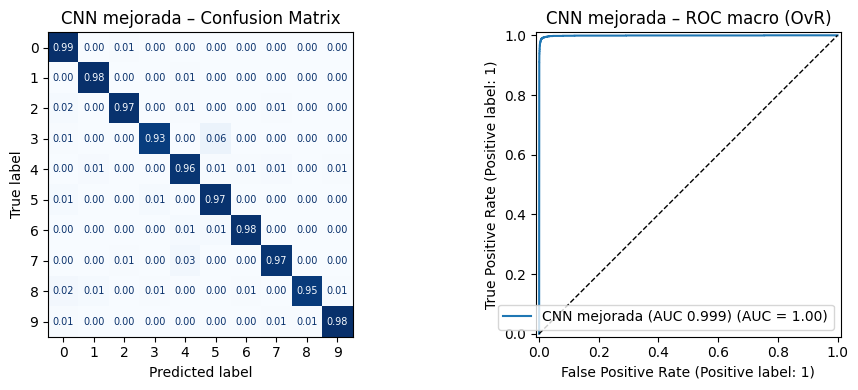

In [16]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ------------------ Helper: Confusion + ROC en 1×2 ------------------
def plot_confusion_roc(model_name, y_true, y_pred, y_score, classes=np.arange(10)):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # Confusion Matrix normalizada
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize='true', values_format='.2f',
        cmap='Blues', ax=axs[0], colorbar=False)
    axs[0].set_title(f"{model_name} – Confusion Matrix")
    for text in disp.text_.ravel():
        text.set_fontsize(7)

    # ROC macro-average
    y_bin = label_binarize(y_true, classes=classes)
    auc   = roc_auc_score(y_bin, y_score, average='macro')
    RocCurveDisplay.from_predictions(
        y_bin.ravel(), y_score.ravel(),
        ax=axs[1], name=f"{model_name} (AUC {auc:.3f})", linewidth=1.5)
    axs[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axs[1].set_title(f"{model_name} – ROC macro (OvR)")
    plt.tight_layout(); plt.show()

# ------------------ 1. Tensores + normalización ------------------
mean_usps, std_usps = 0.173, 0.332     # pre-calculado sobre X_tr

X_train = (X_tr.reshape(-1, 1, 16, 16) / 255.).astype(np.float32)
X_test  = (X_te.reshape(-1, 1, 16, 16) / 255.).astype(np.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.long)
y_test_t  = torch.tensor(y_te, dtype=torch.long)

train_tf = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.Normalize(mean_usps, std_usps)
])
test_tf  = transforms.Normalize(mean_usps, std_usps)

class NumpyDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, tf): self.X, self.y, self.tf = X, y, tf
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        img = torch.from_numpy(self.X[i])
        return self.tf(img), self.y[i]

dl_train = DataLoader(NumpyDataset(X_train, y_train_t, train_tf),
                      batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
dl_test  = DataLoader(NumpyDataset(X_test,  y_test_t,  test_tf),
                      batch_size=256, shuffle=False)

# ------------------ 2. Arquitectura mejorada ------------------
class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                               # 8×8
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                               # 4×4
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.fc(self.conv(x))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = BetterCNN().to(device)

opt       = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn   = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5,
                                                       patience=3, verbose=True)

# ------------------ 3. Entrenamiento ------------------
EPOCHS = 30
for ep in range(EPOCHS):
    # ---------- entrenamiento ----------
    model.train(); running = 0
    for xb, yb in dl_train:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
        running += loss.item() * xb.size(0)
    train_loss = running / len(dl_train.dataset)

    # ---------- validación ----------
    model.eval(); correct = 0
    with torch.no_grad():
        for xb, yb in dl_test:
            pred = model(xb.to(device)).argmax(1).cpu()
            correct += (pred == yb).sum().item()
    val_acc = correct / len(dl_test.dataset)
    scheduler.step(1 - val_acc)

    # ---------- impresión ----------
    width = len(str(EPOCHS))                 # ancho dinámico según total de épocas
    print(f"Epoch {ep+1:0{width}d}/{EPOCHS} | loss {train_loss:.4f} | val_acc {val_acc:.4f}")

# ------------------ 4. Evaluación y ploteo ------------------
model.eval(); probs, preds = [], []
with torch.no_grad():
    for xb, _ in dl_test:
        p = torch.softmax(model(xb.to(device)), 1).cpu()
        probs.append(p); preds.append(p.argmax(1))
probs = torch.cat(probs).numpy()
preds = torch.cat(preds).numpy()

print("\n=== Métricas finales CNN mejorada ===")
print("Accuracy :", accuracy_score(y_test_t, preds))
print("F1_macro :", f1_score(y_test_t, preds, average='macro'))
print(classification_report(y_test_t, preds, digits=4))

plot_confusion_roc("CNN mejorada", y_test_t.numpy(), preds, probs)


---

## Guardar resultados para dashboard

In [17]:
import numpy as np

# Etiquetas verdaderas (solo se guarda una vez)
np.save("y_test.npy", y_test)  # o y_test_t.cpu().numpy() si quieres asegurar consistencia
np.save("y_train.npy", y_train)
np.save("X_train.npy", X_train)

# --- Proyecciones dimensionales ---
np.save("X_pca.npy", X_pca)
np.save("X_umap_k5.npy",  emb_umap[5])
np.save("X_umap_k15.npy", emb_umap[15])
np.save("X_umap_k50.npy", emb_umap[50])

# --- KNN ---
np.save("y_pred_knn.npy",  y_pred_knn)
np.save("proba_knn.npy",   knn.predict_proba(X_test_std))

# --- SVC ---
np.save("y_pred_svc.npy",  y_pred_svc)
np.save("proba_svc.npy",   svc.predict_proba(X_test_std))

# --- CNN ---
np.save("y_pred_cnn.npy",  preds)  # salida de CNN final
np.save("proba_cnn.npy",   probs)  # salida softmax

## Descargar los archivos desde Colab

In [22]:
from google.colab import files

files_to_download = [
    "y_test.npy",
    "X_pca.npy", "X_umap_k5.npy", "X_umap_k15.npy", "X_umap_k50.npy",
    "y_pred_knn.npy", "proba_knn.npy",
    "y_pred_svc.npy", "proba_svc.npy",
    "y_pred_cnn.npy", "proba_cnn.npy"
]

for fname in files_to_download:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
files.download("proba_cnn.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
files.download("y_train.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
files.download("X_train.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>